In [62]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("1")
print(f"pandas version:{pd.__version__}")
print(f"sqlite3 version:{sqlite3.version}")

1
pandas version:2.2.2
sqlite3 version:2.6.0


In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
df = pd.read_csv('/content/drive/MyDrive/intren/student_performance.csv')
print(f"dataset loaded:{df.shape[0]} students, {df.shape[1]} columns")
print(f"columns:{df.columns.tolist()}")
print('First 3 rows:')
display(df.head(3))

dataset loaded:30 students, 13 columns
columns:['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']
First 3 rows:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [48]:
conn=sqlite3.connect('Collage.db')
cursor=conn.cursor()
df.to_sql(
    name='students',
    con=conn,
    index=False,
    if_exists='replace'
)
cursor.execute('SELECT name FROM sqlite_master WHERE type="table";')
tables = cursor.fetchall()
print(tables)
cursor.execute("SELECT COUNT(*)FROM students")
count=cursor.fetchone()[0]
print(f"databse 'collage.db'created ")
print(f"table 'students'has {count} rows")

[('departments',), ('students',)]
databse 'collage.db'created 
table 'students'has 30 rows


In [49]:
cursor.execute("PRAGMA table_info(students)")
columns_info=cursor.fetchall()
print("table structure of 'students':")
print(f"{'column name' : <25}{'data type' :<12}")
print("-" * 38)
for col in columns_info:
    print(f"{col[1]:<25}{col[2]:<12}")

table structure of 'students':
column name              data type   
--------------------------------------
student_id               INTEGER     
name                     TEXT        
age                      INTEGER     
gender                   TEXT        
department               TEXT        
semester                 INTEGER     
math_score               INTEGER     
science_score            INTEGER     
english_score            INTEGER     
programming_score        INTEGER     
attendance_percentage    INTEGER     
city                     TEXT        
admission_year           INTEGER     


In [50]:
def run_query(sql,description=""):
  if description:
    print(f"\n{'='*55}")
    print(f"{description}")
    print(f"\n{'='*55}")
  result = pd.read_sql_query(sql,conn)
  print(result.to_string(index=False))
  return result


In [51]:
query1 = """SELECT student_id,name,department,math_score,attendance_percentage FROM students  LIMIT 10; """
result1 = run_query(query1,"Query1:First 10 Students (SELECT+LIMIT)")


Query1:First 10 Students (SELECT+LIMIT)

 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [52]:
query2 = """SELECT student_id,name,department,math_score,attendance_percentage FROM students ORDER BY student_id DESC LIMIT 5; """
result1 = run_query(query2,"Query2:Last 5 Students (LIMIT + ORDER BY) ")


Query2:Last 5 Students (LIMIT + ORDER BY) 

 student_id           name       department  math_score  attendance_percentage
       1030 Akanksha Yadav Computer Science          91                     95
       1029     Nitin Jain       Mechanical          75                     84
       1028  Sunita Pillai            Civil          60                     73
       1027  Gaurav Shukla Computer Science          84                     87
       1026     Rekha Nair      Electronics          72                     82


In [53]:
query3 = """SELECT student_id,name,department,programming_score,attendance_percentage FROM students WHERE programming_score BETWEEN 51 AND 74 ORDER BY programming_score ASC LIMIT 5; """
result3 = run_query(query3,"Query3:Top 5 Students by Programming Score (using BETWEEN)")


Query3:Top 5 Students by Programming Score (using BETWEEN)

 student_id          name  department  programming_score  attendance_percentage
       1014 Kavya Nambiar  Mechanical                 51                     91
       1006   Meera Joshi Electronics                 52                     72
       1024 Preeti Saxena  Mechanical                 53                     86
       1003   Rohit Verma Electronics                 55                     78
       1021 Harish Pillai Electronics                 58                     74


In [54]:
query_departments = """SELECT DISTINCT department FROM students; """
_ = run_query(query_departments, "Query to get all unique departments");


Query to get all unique departments

      department
Computer Science
     Electronics
      Mechanical
           Civil


In [55]:
query9 = """SELECT name, department, programming_score FROM students ORDER BY programming_score DESC LIMIT 1;"""
result9= run_query(query9, "Query to find the student with the top programming score");


Query to find the student with the top programming score

      name       department  programming_score
Ananya Das Computer Science                 97


In [56]:
query7 = """SELECT name,math_score,science_score,programming_score,attendance_percentage FROM students where department = 'Computer Science' ORDER BY programming_score DESC;"""
result7 = run_query(query7,"")

          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
   Divya Singh          88             91                 93                     96
Swati Kulkarni          90             87                 92                     94
  Aarav Sharma          85             78                 91                     92
     Amit Bose          86             82                 89                     91
    Suresh Rao          83             86                 88                     88
 Gaurav Shukla          84             79                 87                     87
  Nisha Kapoor          79             84                 83                

In [57]:
query_exclude_below_80 = """SELECT name, department, attendance_percentage FROM students WHERE NOT (attendance_percentage < 80);"""
_ = run_query(query_exclude_below_80, "Query to exclude students with attendance percentage LESS THAN 80");


Query to exclude students with attendance percentage LESS THAN 80

          name       department  attendance_percentage
  Aarav Sharma Computer Science                     92
   Priya Patel Computer Science                     87
   Sneha Reddy       Mechanical                     95
    Arjun Nair Computer Science                     90
   Kiran Kumar            Civil                     85
   Divya Singh Computer Science                     96
    Ananya Das Computer Science                     98
   Vikram Iyer      Electronics                     83
   Pooja Gupta            Civil                     80
    Suresh Rao Computer Science                     88
 Kavya Nambiar       Mechanical                     91
  Ritu Agarwal      Electronics                     93
Swati Kulkarni Computer Science                     94
  Nisha Kapoor Computer Science                     89
   Tanvi Mehta Computer Science                     97
 Preeti Saxena       Mechanical                     

In [58]:
dept_data ={
    'dept_code':['cs','ec','me','ce'],
    'dept_name':['Computer Science','Electronics','Mechanical','Civil'],
    'hod_name':['Dr. A','Dr. B','Dr. C','Dr. D'],
    'esthablished':[1985,1988,1972,1965],
    'intake':[60,60,60,60]

}
dept_df = pd.DataFrame(dept_data)
dept_df.to_sql('departments',conn,if_exists='replace',index=False)
print("created 'deparments'table:")
print(dept_df.to_string(index=False))
dept_map={
    'Computer Science':'cs',
    'Electronics':'ec',
    'Mechanical':'me',
    'Civil':'ce'
}
df['dept_code']=df['department'].map(dept_map)
df.to_sql('students',conn,if_exists='replace',index=False)
print("updated 'students' table:")

created 'deparments'table:
dept_code        dept_name hod_name  esthablished  intake
       cs Computer Science    Dr. A          1985      60
       ec      Electronics    Dr. B          1988      60
       me       Mechanical    Dr. C          1972      60
       ce            Civil    Dr. D          1965      60
updated 'students' table:


In [59]:
query__join="""SELECT
  s.name,s.math_score,d.dept_name,d.hod_name,d.esthablished FROM students AS s INNER JOIN departments AS d ON s.dept_code=d.dept_code ORDER BY s.math_score DESC LIMIT 5;"""
run_query(query__join,"Query: Joining Students and Departments")


Query: Joining Students and Departments

          name  math_score        dept_name hod_name  esthablished
    Ananya Das          95 Computer Science    Dr. A          1985
   Tanvi Mehta          93 Computer Science    Dr. A          1985
    Arjun Nair          92 Computer Science    Dr. A          1985
Akanksha Yadav          91 Computer Science    Dr. A          1985
Swati Kulkarni          90 Computer Science    Dr. A          1985


,name,math_score,dept_name,hod_name,esthablished
0,Ananya Das,95,Computer Science,Dr. A,1985
1,Tanvi Mehta,93,Computer Science,Dr. A,1985
2,Arjun Nair,92,Computer Science,Dr. A,1985
3,Akanksha Yadav,91,Computer Science,Dr. A,1985
4,Swati Kulkarni,90,Computer Science,Dr. A,1985


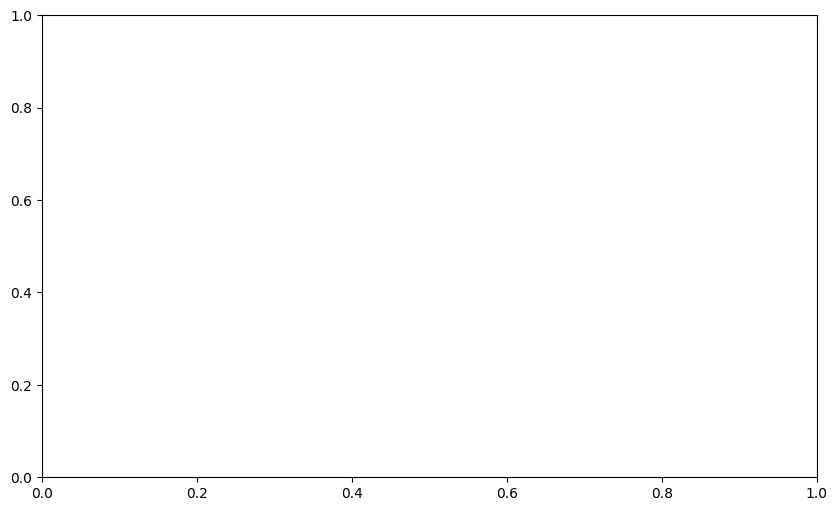

In [60]:
chart1_sql ="""SELECT department,ROUND(AVG(math_score),2) AS avg_math FROM students GROUP BY department ORDER BY avg_math DESC """
chart1_data=pd.read_sql_query(chart1_sql,conn)
fig,ax=plt.subplots(figsize=(10,6))


Query: Top Programming Scores by Gender and Department

gender       department  top_programming_score
Female            Civil                     44
  Male            Civil                     42
Female Computer Science                     97
  Male Computer Science                     95
Female      Electronics                     69
  Male      Electronics                     72
Female       Mechanical                     53
  Male       Mechanical                     50


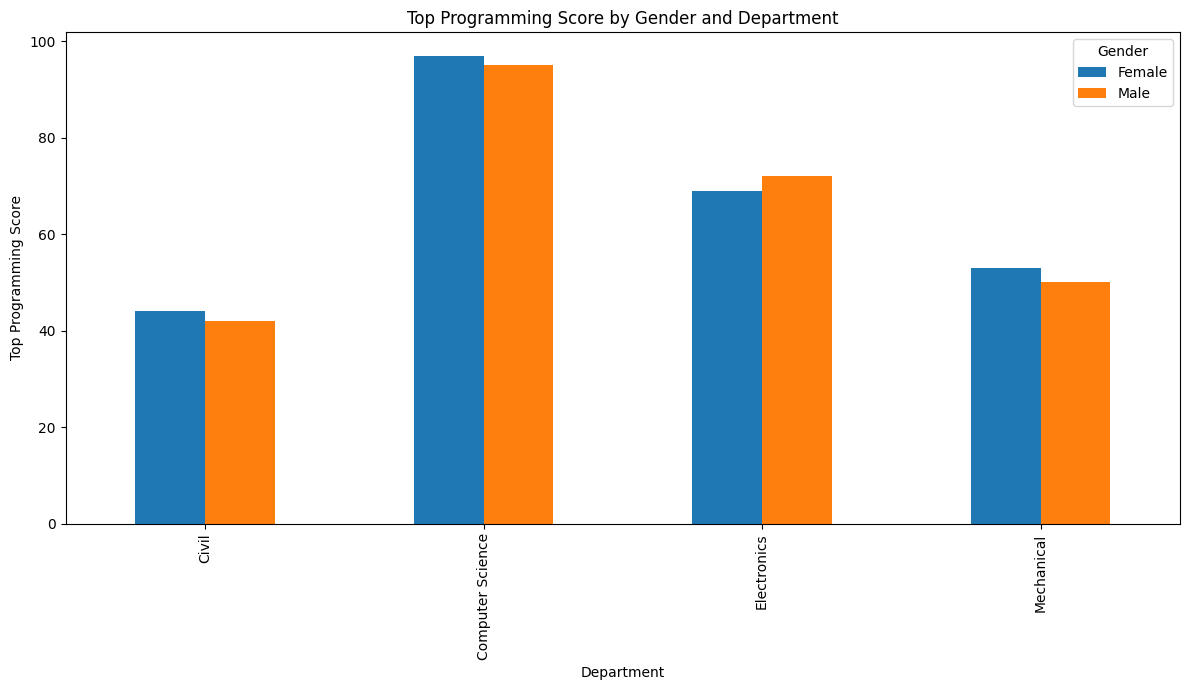

In [65]:
query_top_scores_gender_dept = """ SELECT gender, department, MAX(programming_score) AS top_programming_score FROM students GROUP BY gender, department ORDER BY department, gender; """

top_scores_gender_dept_df = run_query(query_top_scores_gender_dept, "Query: Top Programming Scores by Gender and Department")


pivot_df = top_scores_gender_dept_df.pivot_table(index='department', columns='gender', values='top_programming_score')

fig, ax = plt.subplots(figsize=(12, 7))
pivot_df.plot(kind='bar', ax=ax)

plt.title('Top Programming Score by Gender and Department')
plt.xlabel('Department')
plt.ylabel('Top Programming Score')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

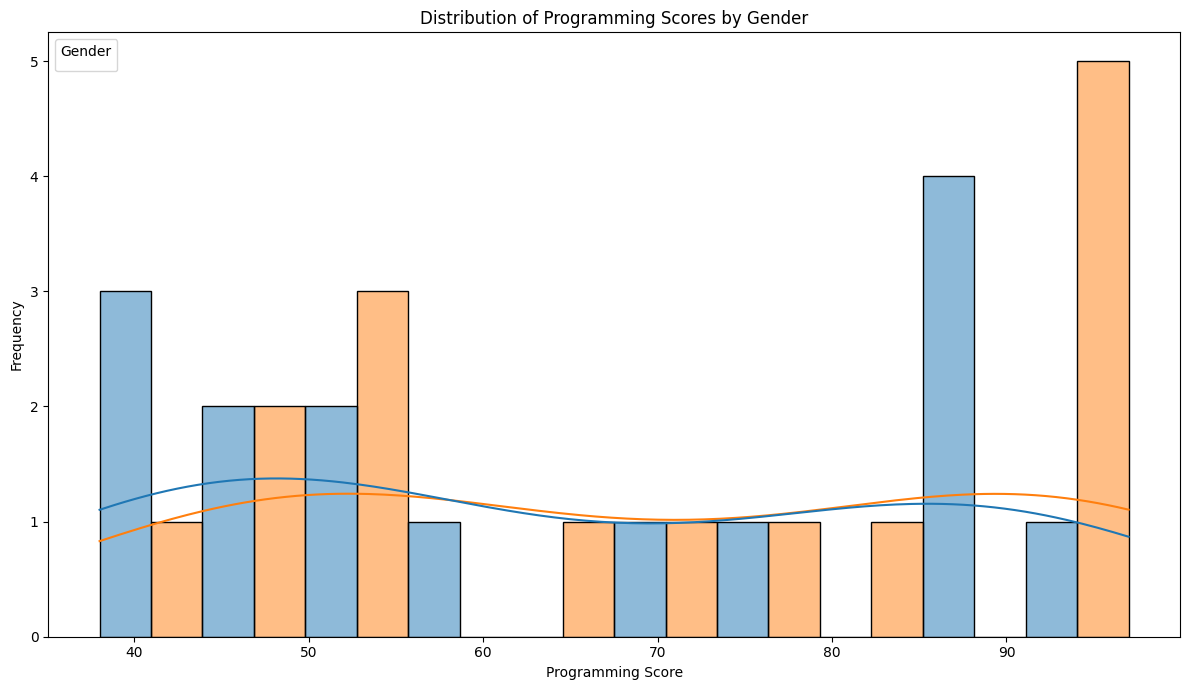

In [66]:
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='programming_score', hue='gender', multiple='dodge', bins=10, kde=True)
plt.title('Distribution of Programming Scores by Gender')
plt.xlabel('Programming Score')
plt.ylabel('Frequency')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

In [67]:
query_q1 = """SELECT AVG(programming_score) AS average_programming_score_female FROM students WHERE gender = 'Female';"""
run_query(query_q1, "Question 1: Average Programming Score for Female Students")


Question 1: Average Programming Score for Female Students

 average_programming_score_female
                             70.2


,average_programming_score_female
0,70.2


In [68]:
query_where_example = """SELECT name, math_score FROM students WHERE math_score > 90;"""
run_query(query_where_example, "Example: WHERE clause (math_score > 90)")


Example: WHERE clause (math_score > 90)

          name  math_score
    Arjun Nair          92
    Ananya Das          95
   Tanvi Mehta          93
Akanksha Yadav          91


,name,math_score
0,Arjun Nair,92
1,Ananya Das,95
2,Tanvi Mehta,93
3,Akanksha Yadav,91


In [69]:
query_having_example = """SELECT department, AVG(programming_score) AS avg_prog_score FROM students GROUP BY department HAVING AVG(programming_score) > 80;"""
run_query(query_having_example, "Example: HAVING clause (average programming score > 80)")


Example: HAVING clause (average programming score > 80)

      department  avg_prog_score
Computer Science       89.230769


,department,avg_prog_score
0,Computer Science,89.230769


In [70]:
query_q3 = """SELECT department, AVG(attendance_percentage) AS average_attendance FROM students GROUP BY department HAVING AVG(attendance_percentage) > 85;"""
run_query(query_q3, "Question 3: Departments with Average Attendance above 85%")


Question 3: Departments with Average Attendance above 85%

      department  average_attendance
Computer Science           90.692308


,department,average_attendance
0,Computer Science,90.692308


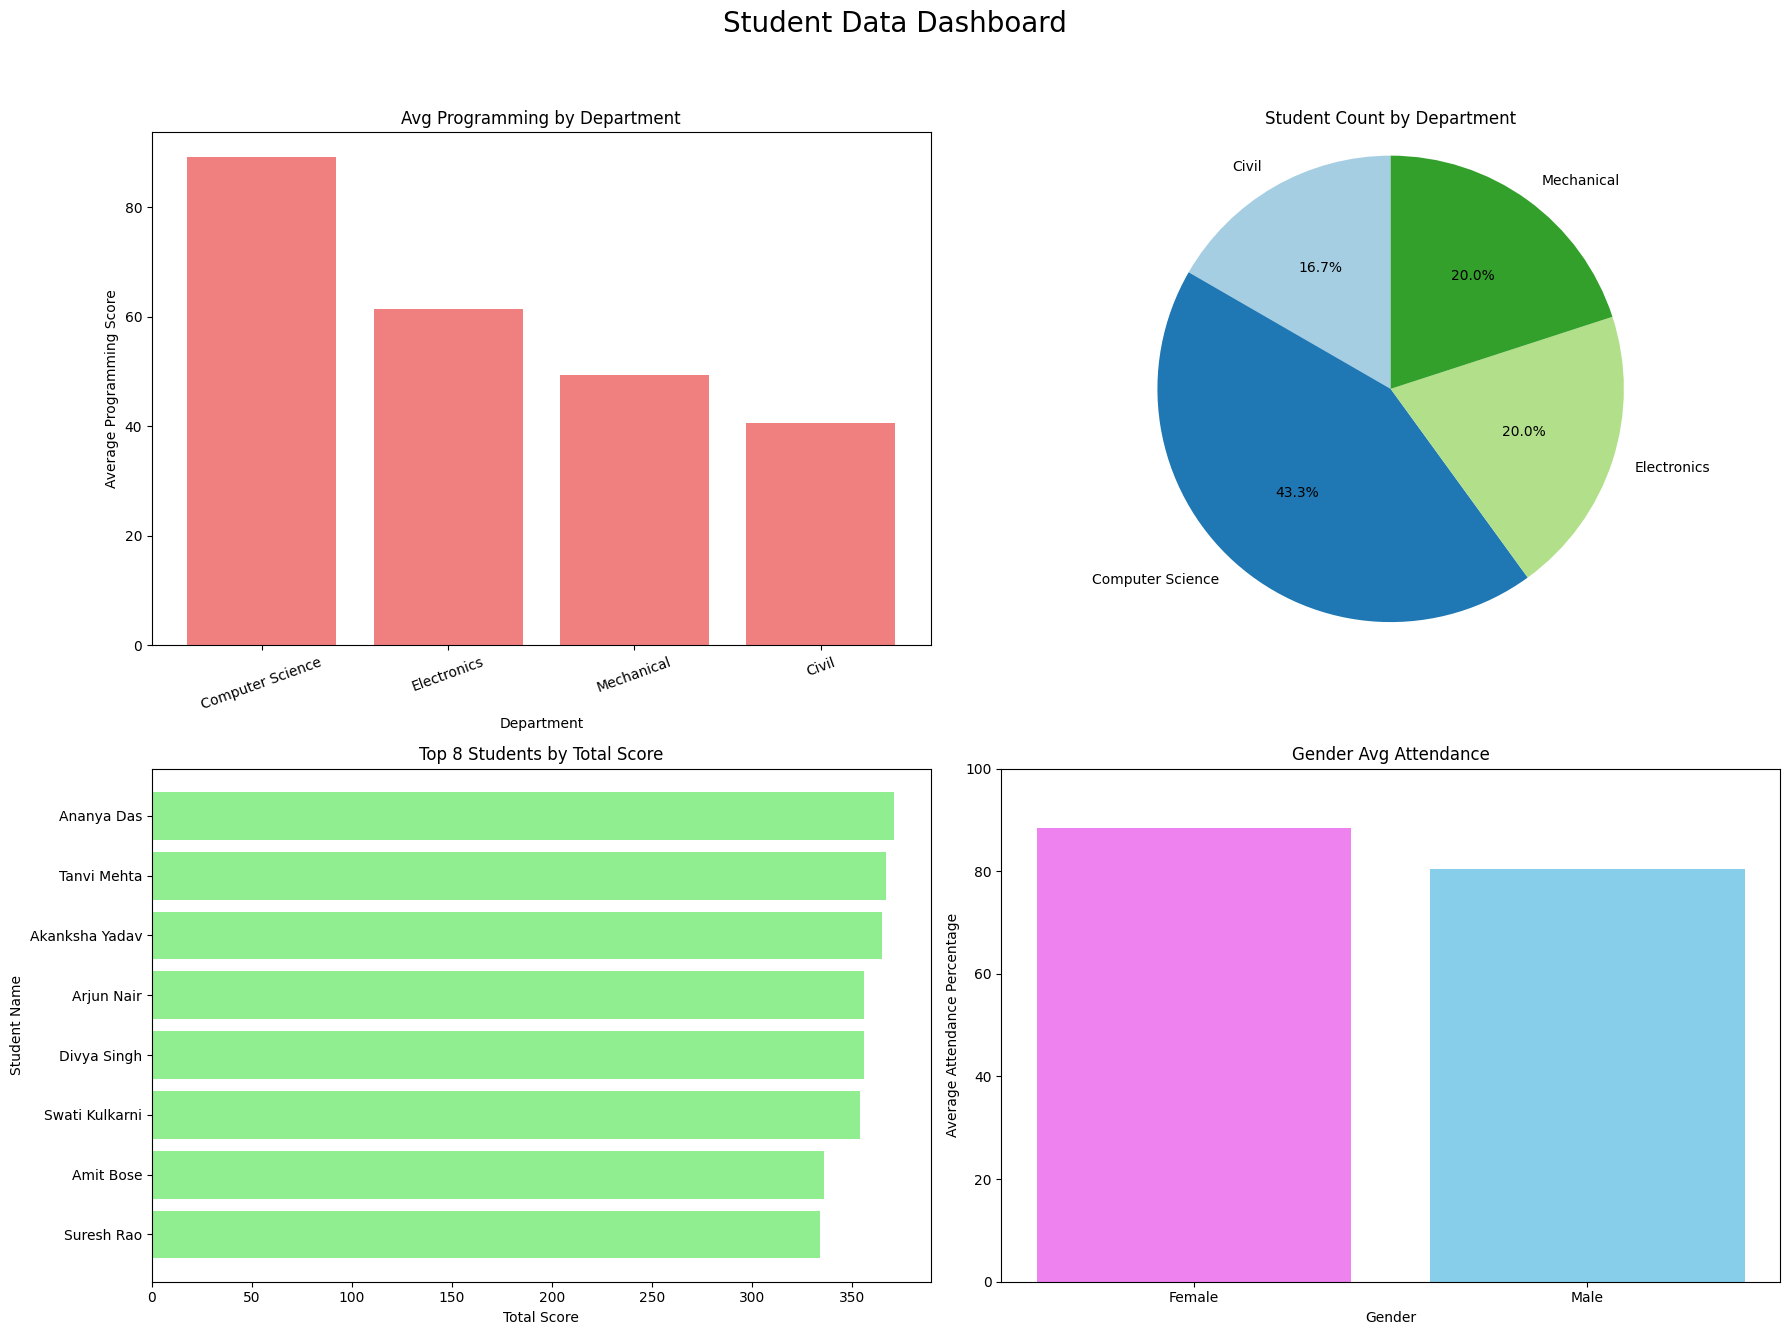

In [74]:
chart1_sql_modified = """SELECT department, ROUND(AVG(programming_score),2) AS avg_programming_score FROM students GROUP BY department ORDER BY avg_programming_score DESC;"""
chart1_df_modified = pd.read_sql_query(chart1_sql_modified, conn)


query_panel2 = """SELECT department, COUNT(student_id) AS student_count FROM students GROUP BY department;"""
panel2_df = pd.read_sql_query(query_panel2, conn)

query_panel3 = """SELECT name, (math_score + science_score + english_score + programming_score) AS total_score FROM students ORDER BY total_score DESC LIMIT 8;"""
panel3_df = pd.read_sql_query(query_panel3, conn)


query_panel4 = """SELECT gender, ROUND(AVG(attendance_percentage), 2) AS average_attendance FROM students GROUP BY gender;"""
panel4_df = pd.read_sql_query(query_panel4, conn)

\
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Student Data Dashboard', fontsize=20)


axes[0, 0].bar(chart1_df_modified['department'], chart1_df_modified['avg_programming_score'], color='lightcoral')
axes[0, 0].set_xlabel('Department')
axes[0, 0].set_ylabel('Average Programming Score')
axes[0, 0].set_title('Avg Programming by Department')
axes[0, 0].tick_params(axis='x', rotation=20)


axes[0, 1].pie(panel2_df['student_count'], labels=panel2_df['department'], autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
axes[0, 1].set_title('Student Count by Department')
axes[0, 1].axis('equal')


axes[1, 0].barh(panel3_df['name'], panel3_df['total_score'], color='lightgreen')
axes[1, 0].set_xlabel('Total Score')
axes[1, 0].set_ylabel('Student Name')
axes[1, 0].set_title('Top 8 Students by Total Score')
axes[1, 0].invert_yaxis()


axes[1, 1].bar(panel4_df['gender'], panel4_df['average_attendance'], color=['violet', 'skyblue'])
axes[1, 1].set_xlabel('Gender')
axes[1, 1].set_ylabel('Average Attendance Percentage')
axes[1, 1].set_title('Gender Avg Attendance')
axes[1, 1].set_ylim(0, 100)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [71]:
query_left_join = """SELECT s.name, s.department, d.hod_name FROM students AS s LEFT JOIN departments AS d ON s.dept_code = d.dept_code;"""
run_query(query_left_join, "Example: LEFT JOIN (Students and Departments)")


Example: LEFT JOIN (Students and Departments)

          name       department hod_name
  Aarav Sharma Computer Science    Dr. A
   Priya Patel Computer Science    Dr. A
   Rohit Verma      Electronics    Dr. B
   Sneha Reddy       Mechanical    Dr. C
    Arjun Nair Computer Science    Dr. A
   Meera Joshi      Electronics    Dr. B
   Kiran Kumar            Civil    Dr. D
   Divya Singh Computer Science    Dr. A
  Rahul Mishra       Mechanical    Dr. C
    Ananya Das Computer Science    Dr. A
   Vikram Iyer      Electronics    Dr. B
   Pooja Gupta            Civil    Dr. D
    Suresh Rao Computer Science    Dr. A
 Kavya Nambiar       Mechanical    Dr. C
   Ajay Tiwari Computer Science    Dr. A
  Ritu Agarwal      Electronics    Dr. B
  Manoj Pandey            Civil    Dr. D
Swati Kulkarni Computer Science    Dr. A
Deepak Chauhan       Mechanical    Dr. C
  Nisha Kapoor Computer Science    Dr. A
 Harish Pillai      Electronics    Dr. B
   Tanvi Mehta Computer Science    Dr. A
  Sanjay 

,name,department,hod_name
0,Aarav Sharma,Computer Science,Dr. A
1,Priya Patel,Computer Science,Dr. A
2,Rohit Verma,Electronics,Dr. B
3,Sneha Reddy,Mechanical,Dr. C
4,Arjun Nair,Computer Science,Dr. A
5,Meera Joshi,Electronics,Dr. B
6,Kiran Kumar,Civil,Dr. D
7,Divya Singh,Computer Science,Dr. A
8,Rahul Mishra,Mechanical,Dr. C
9,Ananya Das,Computer Science,Dr. A


In [72]:

query_right_join_simulated = """SELECT d.dept_name, d.hod_name, s.name FROM departments AS d LEFT JOIN students AS s ON d.dept_code = s.dept_code;"""
run_query(query_right_join_simulated, "Example: RIGHT JOIN (Simulated - Departments and Students)")


Example: RIGHT JOIN (Simulated - Departments and Students)

       dept_name hod_name           name
Computer Science    Dr. A   Aarav Sharma
Computer Science    Dr. A    Ajay Tiwari
Computer Science    Dr. A Akanksha Yadav
Computer Science    Dr. A      Amit Bose
Computer Science    Dr. A     Ananya Das
Computer Science    Dr. A     Arjun Nair
Computer Science    Dr. A    Divya Singh
Computer Science    Dr. A  Gaurav Shukla
Computer Science    Dr. A   Nisha Kapoor
Computer Science    Dr. A    Priya Patel
Computer Science    Dr. A     Suresh Rao
Computer Science    Dr. A Swati Kulkarni
Computer Science    Dr. A    Tanvi Mehta
     Electronics    Dr. B  Harish Pillai
     Electronics    Dr. B    Meera Joshi
     Electronics    Dr. B     Rekha Nair
     Electronics    Dr. B   Ritu Agarwal
     Electronics    Dr. B    Rohit Verma
     Electronics    Dr. B    Vikram Iyer
      Mechanical    Dr. C Deepak Chauhan
      Mechanical    Dr. C  Kavya Nambiar
      Mechanical    Dr. C     Nitin J

,dept_name,hod_name,name
0,Computer Science,Dr. A,Aarav Sharma
1,Computer Science,Dr. A,Ajay Tiwari
2,Computer Science,Dr. A,Akanksha Yadav
3,Computer Science,Dr. A,Amit Bose
4,Computer Science,Dr. A,Ananya Das
5,Computer Science,Dr. A,Arjun Nair
6,Computer Science,Dr. A,Divya Singh
7,Computer Science,Dr. A,Gaurav Shukla
8,Computer Science,Dr. A,Nisha Kapoor
9,Computer Science,Dr. A,Priya Patel


In [73]:

query_full_join_simulated = """SELECT s.name, s.department, d.dept_name, d.hod_name FROM students AS s LEFT JOIN departments AS d ON s.dept_code = d.dept_code UNION ALL SELECT s.name, s.department, d.dept_name, d.hod_name FROM departments AS d LEFT JOIN students AS s ON d.dept_code = s.dept_code WHERE s.name IS NULL;"""
run_query(query_full_join_simulated, "Example: FULL JOIN (Simulated - Students and Departments)")


Example: FULL JOIN (Simulated - Students and Departments)

          name       department        dept_name hod_name
  Aarav Sharma Computer Science Computer Science    Dr. A
   Priya Patel Computer Science Computer Science    Dr. A
   Rohit Verma      Electronics      Electronics    Dr. B
   Sneha Reddy       Mechanical       Mechanical    Dr. C
    Arjun Nair Computer Science Computer Science    Dr. A
   Meera Joshi      Electronics      Electronics    Dr. B
   Kiran Kumar            Civil            Civil    Dr. D
   Divya Singh Computer Science Computer Science    Dr. A
  Rahul Mishra       Mechanical       Mechanical    Dr. C
    Ananya Das Computer Science Computer Science    Dr. A
   Vikram Iyer      Electronics      Electronics    Dr. B
   Pooja Gupta            Civil            Civil    Dr. D
    Suresh Rao Computer Science Computer Science    Dr. A
 Kavya Nambiar       Mechanical       Mechanical    Dr. C
   Ajay Tiwari Computer Science Computer Science    Dr. A
  Ritu Agarw

,name,department,dept_name,hod_name
0,Aarav Sharma,Computer Science,Computer Science,Dr. A
1,Priya Patel,Computer Science,Computer Science,Dr. A
2,Rohit Verma,Electronics,Electronics,Dr. B
3,Sneha Reddy,Mechanical,Mechanical,Dr. C
4,Arjun Nair,Computer Science,Computer Science,Dr. A
5,Meera Joshi,Electronics,Electronics,Dr. B
6,Kiran Kumar,Civil,Civil,Dr. D
7,Divya Singh,Computer Science,Computer Science,Dr. A
8,Rahul Mishra,Mechanical,Mechanical,Dr. C
9,Ananya Das,Computer Science,Computer Science,Dr. A
